In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('WineQT.csv')

In [7]:
df.shape

(1143, 13)

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [8]:
# Drop the 'Id' column (It's just a serial number and has no impact on quality)
df = df.drop('Id', axis=1)

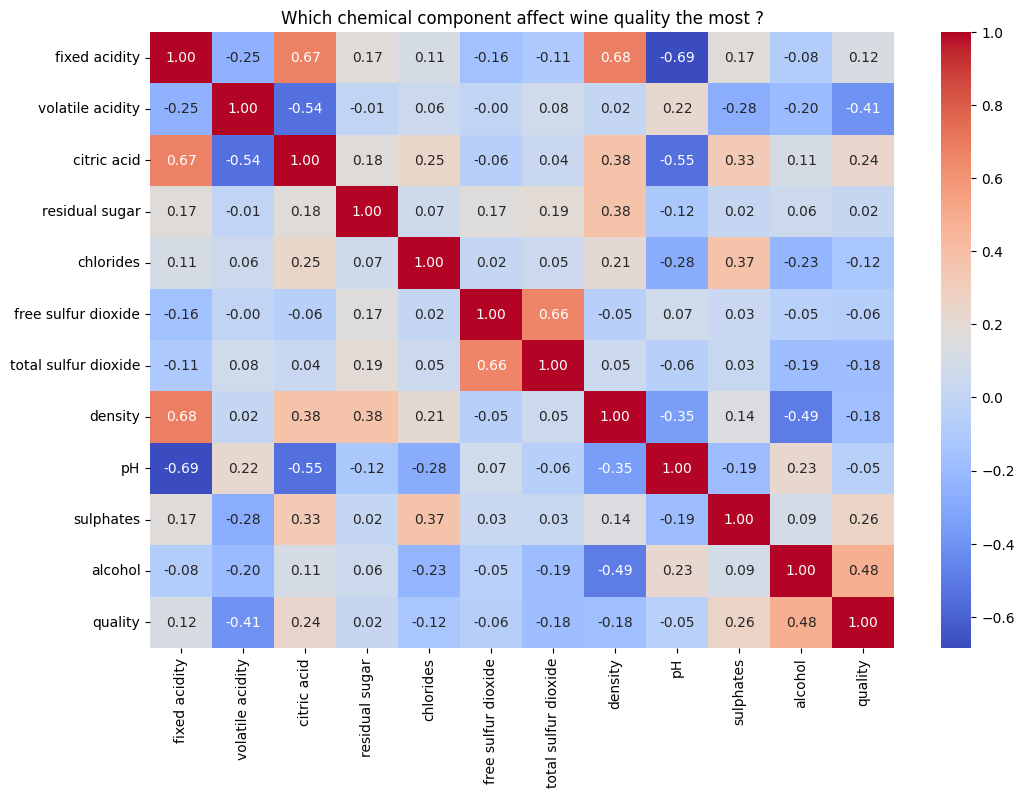

In [9]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Which chemical component affect wine quality the most ?')
plt.show()

In [17]:
# 1. Create the 'quality_label' column 
# We are telling the computer: "If quality is 7 or higher, it's 1 (Good). Otherwise, it's 0 (Bad)."
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

# 2. Check to see if the new column exists now
print("New columns in our dataset:", df.columns)

# 3. NOW you can split the data
# We drop 'quality' (the old 5,6,7 scores) and 'quality_label' from X because X should only be chemistry.
X = df.drop(['quality', 'quality_label'], axis=1) 
y = df['quality_label'] # Our new target

print("\nSuccess! X and y are now ready.")

New columns in our dataset: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'quality_label'],
      dtype='str')

Success! X and y are now ready.


In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(['quality', 'quality_label'], axis=1) # Features (The Chemistry)
y = df['quality_label']                         # Target (The Label)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Training the 'Classifier'
# We use a Classifier now because we are predicting Categories (Good/Bad)
wine_model = RandomForestClassifier(n_estimators=100, random_state=42)
wine_model.fit(X_train_scaled, y_train)

# 3. Evaluation
y_pred = wine_model.predict(X_test_scaled)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 91.70%

Detailed Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       201
           1       0.70      0.57      0.63        28

    accuracy                           0.92       229
   macro avg       0.82      0.77      0.79       229
weighted avg       0.91      0.92      0.91       229



In [25]:
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# 1. SVC (Support Vector Classifier)
# We use 'rbf' kernel for non-linear relationships
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train_scaled, y_train)
svc_pred = svc_model.predict(X_test_scaled)

# 2. SGD (Stochastic Gradient Descent)
# This represents the Gradient Descent requirement in your brief
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train_scaled, y_train)
sgd_pred = sgd_model.predict(X_test_scaled)

print(f"SVC Accuracy: {accuracy_score(y_test, svc_pred):.2%}")
print(f"SGD (Gradient Descent) Accuracy: {accuracy_score(y_test, sgd_pred):.2%}")

SVC Accuracy: 89.08%
SGD (Gradient Descent) Accuracy: 86.90%


C:\Users\Deepanshu Rai\AppData\Local\Temp\ipykernel_9856\2040893856.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


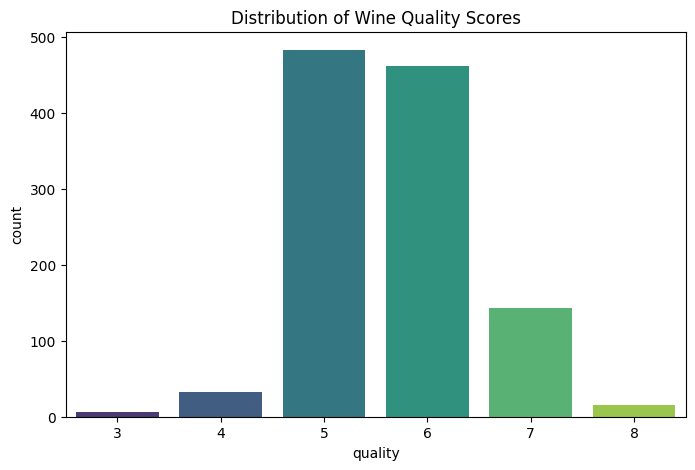

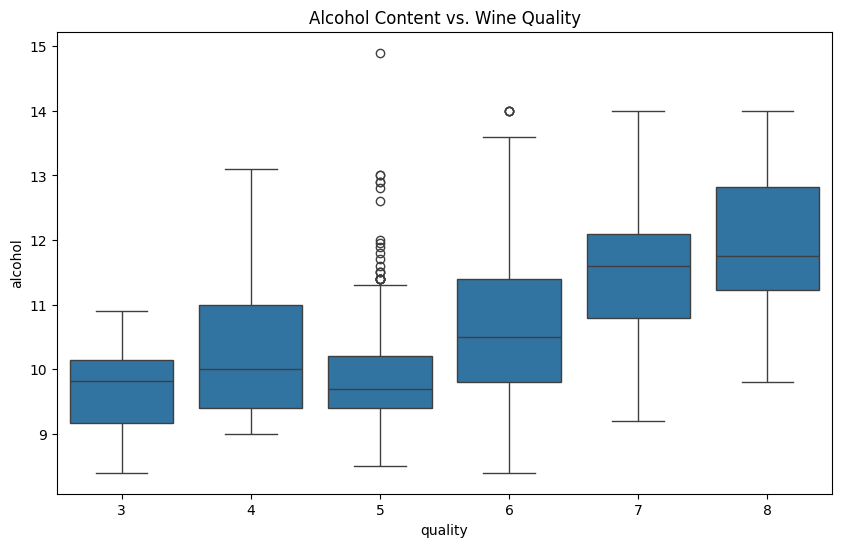

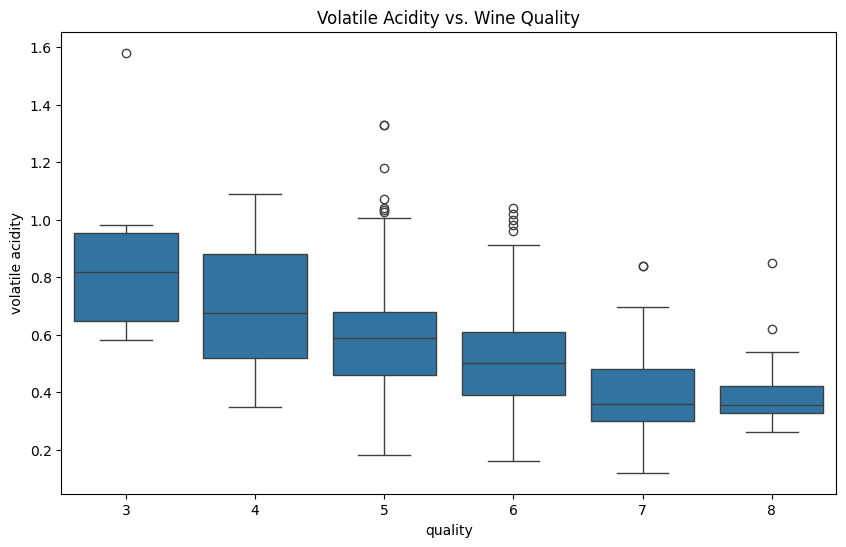

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Wine Quality
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution of Wine Quality Scores')
plt.show()

# 2. Relationship between Alcohol and Quality (The strongest influencer)
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol Content vs. Wine Quality')
plt.show()

# 3. Volatile Acidity vs Quality (The 'Vinegar' factor)
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Volatile Acidity vs. Wine Quality')
plt.show()